# 01 · YOLO26-seg — internal analysis (drill-down)

**Run order of `analysis/`:** **01 internal analysis (this notebook — usable from the first epoch of Phase 1)** →
02 segmentation visualizer → 03 metrics and efficiency → 04 cross-architecture results (02–04 need Phase 5).

Model-specific drill-down, complementing `03_metrics_and_efficiency.ipynb` (per-architecture Phase 5 summary) and
`04_cross_architecture_results.ipynb` (cross-architecture comparison). It follows the plots tracked in the legacy
notebooks (`analysis/legacy/`) — loss and metric curves, train-vs-val gap, convergence and stability, per-fold CV spread,
HPO convergence and hyperparameter–fitness correlation, qualitative overlays — on the outputs of the 5-phase pipeline:

| Section | Reads | Needs |
|---|---|---|
| 0 Inventory | every `results.csv` / `run_state.json` under `logs/<pipeline>/` | anything |
| 1–3 Training curves, overfitting, convergence | `phase1_baseline/`, `phase4_optimized/` | Phase 1 (Phase 4 optional) |
| 4 Cross-validation | `phase2_cv_baseline/` | Phase 2 (partial folds are plotted) |
| 5 HPO | `phase3_hpo/` | Phase 3 (partial searches are plotted) |
| 6 Test metrics (DSC, JSI, Boundary IoU, NSD, HD95) | `summary/test_accuracy.csv`, `phase5_test/per_image/` | Phase 5 |
| 7 Segmentation grid | `phase5_test/masks/`, dataset images and official masks | Phase 5 |
| 8 Size comparison (n, s, m, l, x) | all of the above | Phase 1 (validation panels), Phase 5 (test panels) |

**Granular phase guards — safe to "Run All" at any time.** There is no notebook-wide Phase 5 switch: each section
checks only the phase it plots. Phase 1 curves appear as soon as `phase1_baseline/<run>/results.csv` has its first
epoch (runs still training are labelled `running` and plotted up to the last logged epoch); a phase without output
skips only its own cells with a message such as "⚠️ Phase 2 CV results not yet generated. Skipping the CV plots." Validation figures
(Phases 1–4) are selection-biased (same 100-image split selects the checkpoint); claims rest on the Phase 5 test set.

In [1]:
# ---- Configuration ----------------------------------------------------------
PIPELINE_NAME = "pipeline_final_v1"   # sub-directory of logs/ (or set $PIPELINE_DIR)
ARCH = "YOLO26-seg"
MODELS = ["nano", "small", "medium", "large", "xlarge"]
RUN_NAMES = {"phase1": "yolo26_{m}_baseline", "phase4": "yolo26_{m}_optimized", "cv": "yolo26_{m}", "tune": "tune_{m}"}
LOSS_COLS = [("train/seg_loss", "val/seg_loss", "seg loss"), ("train/box_loss", "val/box_loss", "box loss"),
             ("train/cls_loss", "val/cls_loss", "cls loss"), ("train/dfl_loss", "val/dfl_loss", "dfl loss")]   # (train column, val column, label); the first is the primary loss
METRIC_COLS = {"metrics/mAP50-95(M)": "mask mAP50-95", "metrics/mAP50-95(B)": "box mAP50-95",
               "metrics/mAP50(M)": "mask mAP50", "metrics/precision(M)": "mask precision",
               "metrics/recall(M)": "mask recall"}
PRIMARY = "metrics/mAP50-95(M)"              # main validation metric in the curves
SELECTION = "fitness"   # Ultralytics fitness = box + mask mAP50-95 on val; ties -> latest epoch
TIES = "latest"
LR_COL = "lr/pg0"
TIME_COL, TIME_CUMULATIVE = "time", True   # Ultralytics logs elapsed time; the others per-epoch time
BUDGET = {"phase1": 120, "phase2": 120, "phase3": 30, "phase4": 120}   # epochs per run (patience = epochs: no early stopping)
FITNESS_LABEL = "Ultralytics fitness (box + mask mAP50-95, val)"
PRECISION = "fp32"                    # predicted masks are saved for FP32 only
N_RANDOM, N_HARDEST = 4, 4            # rows of the segmentation grid
SEED = 0
SAVE_FIGURES = True                   # PDF + PNG under <pipeline>/figures/internal_analysis/ (or $FIG_DIR)

import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Locate the repository and the pipeline outputs ------------------------
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()


def find_pipeline_dir(name: str) -> Path | None:
    """$PIPELINE_DIR, else the Docker mount, else <repo>/logs/<name>; None if none exists yet."""
    candidates = [os.environ.get("PIPELINE_DIR"), f"/workspace/logs/{name}", REPO_ROOT / "logs" / name]
    for c in candidates:
        if c and Path(c).is_dir():
            return Path(c)
    print(f"[info] pipeline outputs not found; tried {candidates}. Set PIPELINE_DIR.")
    return None


#: Where the YOLO26 dataset (images + labels, the source of truth) may live on the host.
YOLO_DATASET_CANDIDATES = [REPO_ROOT / "datasets" / "isic2018_task1_official",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic2018_task1_official",
                           # earlier export (results produced before the official-release rebuild)
                           REPO_ROOT / "datasets" / "isic_2018_task1_yolo26",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic_2018_task1_yolo26"]


def local_path(p) -> Path:
    """Map /workspace/... paths recorded inside Docker to this machine when run on the host."""
    p = Path(p)
    if p.exists():
        return p
    s = str(p)
    for prefix in ("/workspace/yolo26_dataset/", "/workspace/datasets/isic2018_task1_official/",
                   "/workspace/datasets/isic_2018_task1_yolo26/"):
        if s.startswith(prefix):
            for root in YOLO_DATASET_CANDIDATES:
                if (root / s[len(prefix):]).exists():
                    return root / s[len(prefix):]
    if s.startswith("/workspace/") and (REPO_ROOT / p.relative_to("/workspace")).exists():
        return REPO_ROOT / p.relative_to("/workspace")
    return p

PHASE5_MISSING = "⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution."
PIPELINE_DIR = find_pipeline_dir(PIPELINE_NAME) or REPO_ROOT / "logs" / PIPELINE_NAME
FIG_DIR = Path(os.environ.get("FIG_DIR", PIPELINE_DIR / "figures" / "internal_analysis"))


def missing(phase: str, what: str) -> str:
    """Skip message of one section (only that phase's cells are skipped)."""
    return f"⚠️ {phase} results not yet generated. Skipping {what}."


# ---- Figure style (publication, light; as notebooks 01/02) ------------------
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#ffffff"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "axes.edgecolor": INK_2, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "legend.frameon": False, "legend.fontsize": 8, "lines.linewidth": 1.6, "lines.markersize": 6,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
PHASE_COLOR = {"phase1": "#eb6834", "phase4": "#1baf7a", "phase2": "#2a78d6", "phase3": "#4a3aa7"}
PHASE_LABEL = {"phase1": "Ph1 Baseline", "phase2": "Ph2 CV", "phase3": "Ph3 HPO", "phase4": "Ph4 Optimized"}
VARIANT_COLOR = {"baseline": PHASE_COLOR["phase1"], "optimized": PHASE_COLOR["phase4"]}
PREC_COLOR = {"fp32": "#2a78d6", "fp16": "#4a3aa7"}
MODEL_COLOR = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#c2185b"]))
SHORT = {"nano": "n", "small": "s", "medium": "m", "large": "l", "xlarge": "x"}


def save(fig, name: str) -> None:
    """Save a figure as vector PDF (for LaTeX) and 300-dpi PNG under FIG_DIR."""
    if not SAVE_FIGURES:
        return
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
    print(f"saved {FIG_DIR / name}.pdf|png")


print("pipeline :", PIPELINE_DIR, "" if PIPELINE_DIR.is_dir() else "(not created yet)")
print("figures  :", FIG_DIR)

pipeline : /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1 
figures  : /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis


## 0. Inventory — what exists right now

One row per training run found under the pipeline folder. `status` comes from `run_state.json` (`running` = still
training, the curves below stop at the last logged epoch). Duplicate epoch rows (a run resumed after dying between the
log write and the checkpoint) are collapsed to the last record, as in the pipeline's own report.

In [2]:
def read_results(path: Path) -> pd.DataFrame:
    """results.csv of one run: numeric, one row per epoch (last record wins), torn lines of a live run skipped."""
    try:
        df = pd.read_csv(path, on_bad_lines="skip")
    except (pd.errors.EmptyDataError, pd.errors.ParserError, OSError, UnicodeDecodeError) as err:
        print(f"[skip] {path}: {err}")
        return pd.DataFrame()
    df.columns = [c.strip() for c in df.columns]
    if "epoch" not in df or df.empty:
        return pd.DataFrame()
    for c in df.columns:
        if c != "improved":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df[df["epoch"].notna()].astype({"epoch": int})
    df = df.drop_duplicates("epoch", keep="last").sort_values("epoch").reset_index(drop=True)
    if SELECTION == "fitness":
        df["fitness"] = df.get("metrics/mAP50-95(B)", np.nan) + df.get("metrics/mAP50-95(M)", np.nan)
    if TIME_COL in df:
        df["hours"] = (df[TIME_COL] if TIME_CUMULATIVE else df[TIME_COL].cumsum()) / 3600
    return df


def best_row(df: pd.DataFrame) -> pd.Series | None:
    """Epoch selected as best.pt by the framework's rule (see SELECTION / TIES)."""
    if df.empty or SELECTION not in df or df[SELECTION].notna().sum() == 0:
        return None
    s = df[SELECTION]
    hits = df.index[s == s.max()]
    return df.loc[hits[-1] if TIES == "latest" else hits[0]]


def run_status(run_dir: Path) -> str:
    try:
        return json.loads((run_dir / "run_state.json").read_text()).get("status", "?")
    except (OSError, ValueError):
        return "?"


RUNS = []   # dicts: phase, model, label, dir, df, status


def add_run(phase: str, model: str, label: str, csv: Path) -> None:
    if not csv.exists():
        return
    df = read_results(csv)
    if len(df):
        RUNS.append(dict(phase=phase, model=model, label=label, dir=csv.parent, df=df, status=run_status(csv.parent)))


TUNE = {}   # model -> tune_results.csv (one row per completed trial)
CV_PIXELS = {}   # model -> pixel_metrics_per_fold.csv (Phase 2, dataset resolution)
for m in MODELS:
    for ph in ("phase1", "phase4"):
        add_run(ph, m, "baseline" if ph == "phase1" else "optimized",
                PIPELINE_DIR / f"{ph}_{'baseline' if ph == 'phase1' else 'optimized'}" / RUN_NAMES[ph].format(m=m) / "results.csv")
    cv_dir = PIPELINE_DIR / "phase2_cv_baseline" / RUN_NAMES["cv"].format(m=m)
    for csv in sorted((cv_dir / "runs").glob("fold_*/results.csv")):
        add_run("phase2", m, csv.parent.name, csv)
    if (cv_dir / "pixel_metrics_per_fold.csv").exists():
        CV_PIXELS[m] = pd.read_csv(cv_dir / "pixel_metrics_per_fold.csv")
    tune_dir = PIPELINE_DIR / "phase3_hpo" / RUN_NAMES["tune"].format(m=m)
    for csv in sorted((tune_dir / "trials").glob("*/results.csv")):
        add_run("phase3", m, csv.parent.name, csv)
    if (tune_dir / "tune_results.csv").exists():
        t = pd.read_csv(tune_dir / "tune_results.csv", on_bad_lines="skip")
        if len(t):
            TUNE[m] = t.reset_index(drop=True)

SUMMARY = PIPELINE_DIR / "summary"
HAVE = {ph: any(r["phase"] == ph for r in RUNS) for ph in ("phase1", "phase2", "phase3", "phase4")}
HAVE["phase3"] = HAVE["phase3"] or bool(TUNE)
HAVE["phase5"] = (SUMMARY / "test_accuracy.csv").exists()

rows = []
for r in RUNS:
    b = best_row(r["df"])
    rows.append({"phase": PHASE_LABEL[r["phase"]], "model": r["model"], "run": r["label"], "status": r["status"],
                 "epochs logged": int(r["df"].epoch.max()), "budget": BUDGET[r["phase"]],
                 "best epoch": None if b is None else int(b.epoch),
                 f"best {METRIC_COLS.get(PRIMARY, PRIMARY)}": None if b is None else b.get(PRIMARY),
                 "hours": round(float(r["df"]["hours"].iloc[-1]), 2) if "hours" in r["df"] else None})
INVENTORY = pd.DataFrame(rows)
STATUS_NAME = {"phase1": "Phase 1 Baseline", "phase2": "Phase 2 CV", "phase3": "Phase 3 HPO",
               "phase4": "Phase 4 Optimized", "phase5": "Phase 5 Test"}
for ph, ok in HAVE.items():
    runs_ph = [r for r in RUNS if r["phase"] == ph]
    detail = (f"{len(runs_ph)} run(s): " + ", ".join(sorted({r["status"] for r in runs_ph}))) if runs_ph else ""
    print(f"{'✅' if ok else '·· '} {STATUS_NAME[ph]:<18} {detail if ok else 'not yet generated'}")
if INVENTORY.empty:
    print(missing("Phase 1–4 training", "the inventory table"))
else:
    # HPO trials are summarised in section 5; list them here only as a count
    is_trial = INVENTORY.phase == PHASE_LABEL["phase3"]
    if is_trial.any():
        print(f"Phase 3: {is_trial.sum()} trial runs logged —", INVENTORY[is_trial].groupby("model").size().to_dict())
    display(INVENTORY[~is_trial].round(4))

✅ Phase 1 Baseline   5 run(s): complete
✅ Phase 2 CV         7 run(s): complete, running
··  Phase 3 HPO        not yet generated
··  Phase 4 Optimized  not yet generated
··  Phase 5 Test       not yet generated


,phase,model,run,status,epochs logged,budget,best epoch,best mask mAP50-95,hours
0,Ph1 Baseline,nano,baseline,complete,120,120,69,0.7158,1.70
1,Ph2 CV,nano,fold_0,complete,120,120,73,0.7313,1.50
2,Ph2 CV,nano,fold_1,complete,120,120,79,0.7289,2.79
3,Ph2 CV,nano,fold_2,complete,120,120,107,0.7306,1.75
4,Ph2 CV,nano,fold_3,complete,120,120,91,0.7070,1.53
5,Ph2 CV,nano,fold_4,complete,120,120,102,0.7261,1.53
6,Ph1 Baseline,small,baseline,complete,120,120,37,0.7040,2.50
7,Ph2 CV,small,fold_0,complete,120,120,79,0.7310,2.73
8,Ph2 CV,small,fold_1,running,19,120,18,0.6712,0.36
9,Ph1 Baseline,medium,baseline,complete,120,120,57,0.7018,4.52


## 1. Training curves — Phases 1 and 4

Loss (train and validation) and the validation metrics per epoch; ● marks the epoch kept as `best.pt` by the
framework's selection rule. Solid = Phase 1 Baseline, dashed = Phase 4 Optimized; colour = model size.

ℹ️ Phase 4 (Optimized) not yet generated — showing Phase 1 only.
saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_training_curves.pdf|png


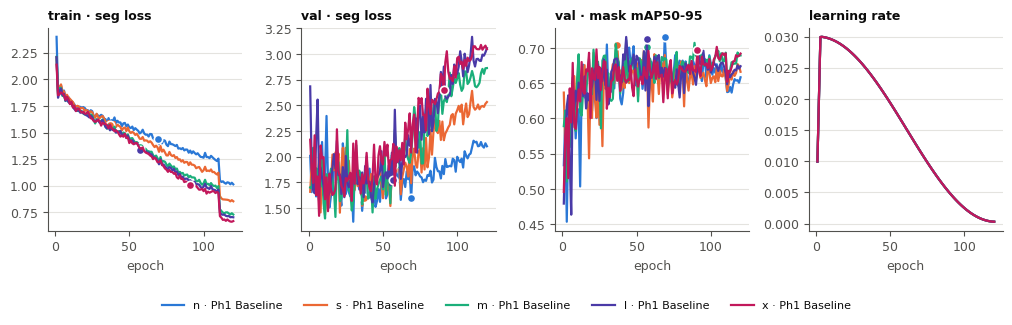

saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_validation_metrics.pdf|png


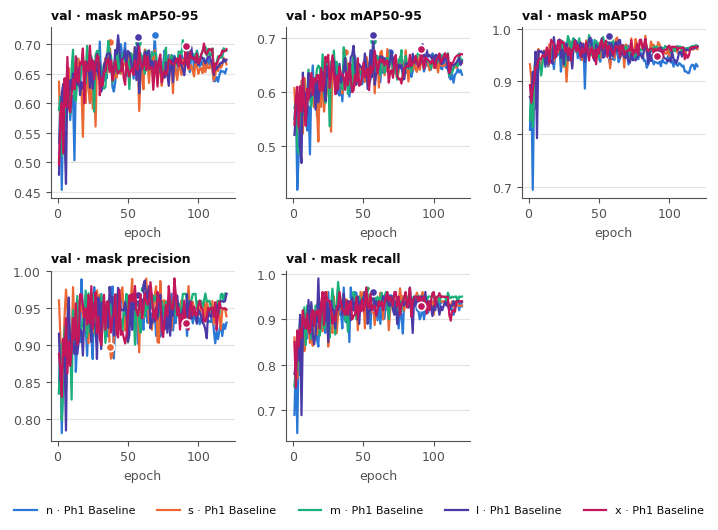

saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_loss_components.pdf|png


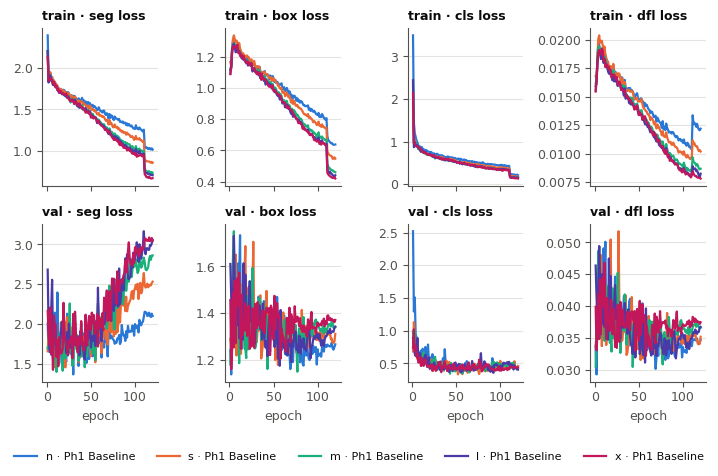

In [3]:
def runs_of(*phases):
    return [r for r in RUNS if r["phase"] in phases]


def line_style(r):
    """Colour: model size (YOLO26) or phase; line style: phase."""
    color = MODEL_COLOR[r["model"]] if len(MODELS) > 1 else PHASE_COLOR[r["phase"]]
    return dict(color=color, linestyle="-" if r["phase"] == "phase1" else "--")


def run_label(r):
    tag = f"{SHORT.get(r['model'], r['model'])} · " if len(MODELS) > 1 else ""
    return f"{tag}{PHASE_LABEL[r['phase']]}" + (" (running)" if r["status"] == "running" else "")


def plot_curves(ax, runs, col, mark_best=True):
    for r in runs:
        df = r["df"]
        if col not in df or df[col].notna().sum() == 0:
            continue
        ax.plot(df.epoch, df[col], label=run_label(r), **line_style(r))
        b = best_row(df)
        if mark_best and b is not None and pd.notna(b.get(col)):
            ax.plot(b.epoch, b[col], "o", color=line_style(r)["color"], markeredgecolor=SURFACE, markeredgewidth=1.2)


def section_training_curves():
    runs = runs_of("phase1", "phase4")
    if not runs:
        print(missing("Phase 1 (Baseline)", "the training-curve plots"))
        return
    if not HAVE["phase4"]:
        print("ℹ️ Phase 4 (Optimized) not yet generated — showing Phase 1 only.")
    train_col, val_col, loss_label = LOSS_COLS[0]
    panels = [(train_col, f"train · {loss_label}"), (val_col, f"val · {loss_label}"),
              (PRIMARY, f"val · {METRIC_COLS.get(PRIMARY, PRIMARY)}")]
    if LR_COL:
        panels.append((LR_COL, "learning rate"))
    fig, axes = plt.subplots(1, len(panels), figsize=(2.4 * len(panels) + 0.6, 2.9), squeeze=False)
    for ax, (col, title) in zip(axes[0], panels):
        plot_curves(ax, runs, col, mark_best=col != LR_COL)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("epoch")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.12))
    fig.tight_layout()
    save(fig, "internal_training_curves")
    plt.show()

    metrics = [c for c in METRIC_COLS if any(c in r["df"] and r["df"][c].notna().any() for r in runs)]
    if metrics:
        ncol = min(3, len(metrics))
        nrow = -(-len(metrics) // ncol)
        fig, axes = plt.subplots(nrow, ncol, figsize=(7.2, 2.5 * nrow), squeeze=False)
        for ax, col in zip(axes.flat, metrics):
            plot_curves(ax, runs, col)
            ax.set_title(f"val · {METRIC_COLS[col]}", fontsize=9)
            ax.set_xlabel("epoch")
        for ax in list(axes.flat)[len(metrics):]:
            ax.set_visible(False)
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.06))
        fig.tight_layout()
        save(fig, "internal_validation_metrics")
        plt.show()

    if len(LOSS_COLS) > 1:   # every loss component, train (top) and val (bottom)
        fig, axes = plt.subplots(2, len(LOSS_COLS), figsize=(7.2, 4.4), squeeze=False, sharex=True)
        for j, (tc, vc, lab) in enumerate(LOSS_COLS):
            plot_curves(axes[0, j], runs, tc, mark_best=False)
            plot_curves(axes[1, j], runs, vc, mark_best=False)
            axes[0, j].set_title(f"train · {lab}", fontsize=9)
            axes[1, j].set_title(f"val · {lab}", fontsize=9)
            axes[1, j].set_xlabel("epoch")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, -0.08))
        fig.tight_layout()
        save(fig, "internal_loss_components")
        plt.show()


section_training_curves()

## 2. Overfitting check — validation minus training loss

A growing gap means the model fits the training images better than it generalises (legacy "train vs val seg_loss"
plot). The gap is read alongside the validation metric: a rising gap with a flat metric is benign.

saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_generalisation_gap.pdf|png


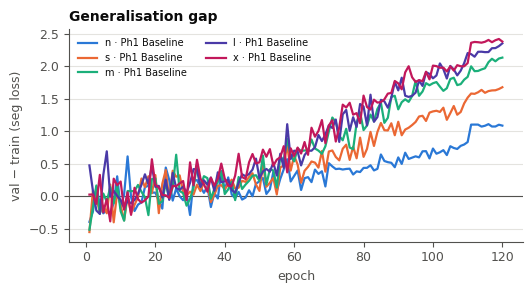

In [4]:
def section_overfitting():
    runs = runs_of("phase1", "phase4")
    train_col, val_col, loss_label = LOSS_COLS[0]
    runs = [r for r in runs if train_col in r["df"] and val_col in r["df"] and r["df"][val_col].notna().any()]
    if not runs:
        print(missing("Phase 1 (Baseline)", "the generalisation-gap plot"))
        return
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    ax.axhline(0, color=INK_2, linewidth=0.8)
    for r in runs:
        ax.plot(r["df"].epoch, r["df"][val_col] - r["df"][train_col], label=run_label(r), **line_style(r))
    ax.set_xlabel("epoch")
    ax.set_ylabel(f"val − train ({loss_label})")
    ax.set_title("Generalisation gap")
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    save(fig, "internal_generalisation_gap")
    plt.show()


section_overfitting()

## 3. Convergence and stability

Per run: the best epoch, how many epochs it took to reach 95 % of the best validation value (convergence speed), the
standard deviation of the metric over the last 10 logged epochs (stability) and the training time.

In [5]:
def section_convergence():
    runs = runs_of("phase1", "phase4")
    if not runs:
        print(missing("Phase 1 (Baseline)", "the convergence table"))
        return
    rows = []
    for r in runs:
        df, b = r["df"], best_row(r["df"])
        s = df[PRIMARY] if PRIMARY in df else pd.Series(dtype=float)
        lower_better = "hd95" in PRIMARY
        target = s.min() / 0.95 if lower_better else 0.95 * s.max()
        reached = df.epoch[(s <= target) if lower_better else (s >= target)]
        rows.append({"model": r["model"], "run": PHASE_LABEL[r["phase"]], "status": r["status"],
                     "epochs logged": int(df.epoch.max()), "best epoch": None if b is None else int(b.epoch),
                     f"best {METRIC_COLS.get(PRIMARY, PRIMARY)}": None if b is None else b.get(PRIMARY),
                     "epochs to 95 % of best": int(reached.min()) if len(reached) else None,
                     "SD last 10 epochs": float(s.tail(10).std(ddof=1)) if s.notna().sum() >= 2 else None,
                     "hours": float(df["hours"].iloc[-1]) if "hours" in df else None})
    display(pd.DataFrame(rows).round(4))


section_convergence()

,model,run,status,epochs logged,best epoch,best mask mAP50-95,epochs to 95 % of best,SD last 10 epochs,hours
0,nano,Ph1 Baseline,complete,120,69,0.7158,30,0.0082,1.7024
1,small,Ph1 Baseline,complete,120,37,0.7040,11,0.0115,2.5037
2,medium,Ph1 Baseline,complete,120,57,0.7018,11,0.0121,4.5187
3,large,Ph1 Baseline,complete,120,57,0.7121,28,0.0079,5.2837
4,xlarge,Ph1 Baseline,complete,120,91,0.6967,7,0.0130,10.5049


## 4. Phase 2 — 5-fold cross-validation of the Baseline

Validation curve of every fold (the held-out fold is the per-epoch validation set) and, once the folds are evaluated,
the fold-wise pixel metrics of each fold's `best.pt` at the dataset resolution — mean ± sample SD (ddof = 1). The
folds share training data, so the SD describes variability; it is not the basis of a test.

saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_cv_curves.pdf|png


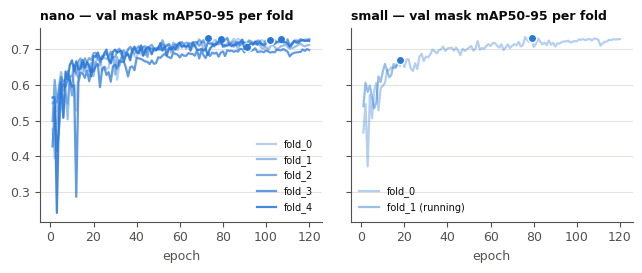

,model,fold,status,epochs logged,best epoch,best mask mAP50-95
0,nano,fold_0,complete,120,73,0.7313
1,nano,fold_1,complete,120,79,0.7289
2,nano,fold_2,complete,120,107,0.7306
3,nano,fold_3,complete,120,91,0.7070
4,nano,fold_4,complete,120,102,0.7261
5,small,fold_0,complete,120,79,0.7310
6,small,fold_1,running,19,18,0.6712


⚠️ Phase 2 fold-wise pixel metrics (pixel_metrics_per_fold.csv) not yet generated — written once every fold has finished. Skipping the fold-metrics plot.


In [6]:
def section_cv():
    runs = runs_of("phase2")
    if not runs and not CV_PIXELS:
        print(missing("Phase 2 CV", "the CV plots"))
        return
    if runs:
        models = [m for m in MODELS if any(r["model"] == m for r in runs)]
        fig, axes = plt.subplots(1, len(models), figsize=(min(7.2, 3.0 * len(models) + 0.6), 2.8), squeeze=False,
                                 sharey=True)
        for ax, m in zip(axes[0], models):
            for r in (r for r in runs if r["model"] == m):
                df = r["df"]
                if PRIMARY not in df:
                    continue
                ax.plot(df.epoch, df[PRIMARY], color=PHASE_COLOR["phase2"], alpha=0.35 + 0.13 * int(r["label"][-1]),
                        label=r["label"] + (" (running)" if r["status"] == "running" else ""))
                b = best_row(df)
                if b is not None:
                    ax.plot(b.epoch, b[PRIMARY], "o", color=PHASE_COLOR["phase2"], markeredgecolor=SURFACE)
            ax.set_title(f"{m} — val {METRIC_COLS.get(PRIMARY, PRIMARY)} per fold" if len(models) > 1
                         else f"val {METRIC_COLS.get(PRIMARY, PRIMARY)} per fold", fontsize=9)
            ax.set_xlabel("epoch")
            ax.legend(fontsize=7)
        fig.tight_layout()
        save(fig, "internal_cv_curves")
        plt.show()
        best = pd.DataFrame([{"model": r["model"], "fold": r["label"], "status": r["status"],
                              "epochs logged": int(r["df"].epoch.max()),
                              "best epoch": None if best_row(r["df"]) is None else int(best_row(r["df"]).epoch),
                              f"best {METRIC_COLS.get(PRIMARY, PRIMARY)}":
                                  None if best_row(r["df"]) is None else best_row(r["df"]).get(PRIMARY)} for r in runs])
        display(best.round(4))
    if not CV_PIXELS:
        print("⚠️ Phase 2 fold-wise pixel metrics (pixel_metrics_per_fold.csv) not yet generated — written once "
              "every fold has finished. Skipping the fold-metrics plot.")
        return
    keys = [k for k in ("dsc", "jsi", "biou", "nsd", "hd95") if any(k in d for d in CV_PIXELS.values())]
    if not keys:
        print("⚠️ pixel_metrics_per_fold.csv has no metric columns — skipped.")
        return
    fig, axes = plt.subplots(1, len(keys), figsize=(7.2, 2.6), squeeze=False)
    for ax, k in zip(axes[0], keys):
        for i, (m, d) in enumerate(CV_PIXELS.items()):
            if k not in d:
                continue
            ax.plot(np.full(len(d), i), d[k], "o", color=PHASE_COLOR["phase2"], alpha=0.6)
            ax.errorbar(i + 0.18, d[k].mean(), yerr=d[k].std(ddof=1), fmt="D", color=INK, capsize=0)
        ax.set_xticks(range(len(CV_PIXELS)), [SHORT.get(m, m) for m in CV_PIXELS])
        ax.set_xlim(-0.5, len(CV_PIXELS) - 0.3)
        ax.set_title(k.upper() + (" (px) ↓" if k == "hd95" else ""), fontsize=9)
    fig.suptitle("Per-fold pixel metrics (dots) and mean ± SD", x=0.01, ha="left", fontsize=10, fontweight="semibold")
    fig.tight_layout()
    save(fig, "internal_cv_folds")
    plt.show()
    summary = pd.concat({m: d[[k for k in keys if k in d]].agg(["mean", lambda x: x.std(ddof=1)]).rename(
        index={"<lambda>": "sd"}) for m, d in CV_PIXELS.items()})
    display(summary.round(4))


section_cv()

## 5. Phase 3 — hyperparameter optimisation

Fitness of every completed trial and the running best (convergence of the search), the Pearson correlation of each
hyperparameter with the fitness (which hyperparameters mattered — legacy HPO explainer), the validation curves of the
trials and the selected configuration (`best_hyperparameters.yaml`). With few trials the correlations are noisy and
descriptive only.

In [7]:
def section_hpo():
    trials = runs_of("phase3")
    if not TUNE and not trials:
        print(missing("Phase 3 HPO", "the HPO plots"))
        return
    if TUNE:
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
        for m, t in TUNE.items():
            c = MODEL_COLOR[m] if len(MODELS) > 1 else PHASE_COLOR["phase3"]
            x = np.arange(1, len(t) + 1)
            axes[0].plot(x, t["fitness"], "o", color=c, alpha=0.45, markersize=4)
            axes[0].plot(x, t["fitness"].cummax(), color=c, label=f"{m} (best so far)")
        axes[0].set_xlabel("trial")
        axes[0].set_ylabel(FITNESS_LABEL, fontsize=8)
        axes[0].set_title("HPO convergence")
        axes[0].legend(fontsize=7)
        corr = pd.DataFrame({m: t.drop(columns="fitness").apply(pd.to_numeric, errors="coerce")
                             .corrwith(t["fitness"]) for m, t in TUNE.items() if len(t) >= 3})
        if corr.empty:
            axes[1].set_visible(False)
        else:
            corr = corr.reindex(corr.abs().max(axis=1).sort_values().index)
            h = 0.8 / corr.shape[1]
            for j, m in enumerate(corr.columns):
                axes[1].barh(np.arange(len(corr)) + j * h, corr[m], height=h,
                             color=MODEL_COLOR[m] if len(MODELS) > 1 else PHASE_COLOR["phase3"], label=m)
            axes[1].set_yticks(np.arange(len(corr)) + 0.4 - h / 2, corr.index, fontsize=7)
            axes[1].axvline(0, color=INK_2, linewidth=0.8)
            axes[1].set_xlabel("Pearson r with fitness")
            axes[1].set_title("Hyperparameter vs fitness")
            axes[1].grid(True, axis="x")
            axes[1].grid(False, axis="y")
        fig.tight_layout()
        save(fig, "internal_hpo")
        plt.show()
        for m, t in TUNE.items():
            best_i = int(t["fitness"].idxmax())
            print(f"{m}: {len(t)} completed trials, best = trial {best_i} (fitness {t['fitness'].max():.4f})")
            yaml_path = PIPELINE_DIR / "phase3_hpo" / RUN_NAMES["tune"].format(m=m) / "best_hyperparameters.yaml"
            if yaml_path.exists():
                print("   best_hyperparameters.yaml:", " ".join(l for l in yaml_path.read_text().splitlines()
                                                           if l and not l.startswith("#")))
    else:
        print("⚠️ Phase 3 tune_results.csv not yet generated — the first trial is still running. "
              "Skipping the convergence plot.")
    if trials:
        models = [m for m in MODELS if any(r["model"] == m for r in trials)]
        fig, axes = plt.subplots(1, len(models), figsize=(min(7.2, 3.0 * len(models) + 0.6), 2.7), squeeze=False,
                                 sharey=True)
        for ax, m in zip(axes[0], models):
            for r in (r for r in trials if r["model"] == m):
                if PRIMARY in r["df"]:
                    ax.plot(r["df"].epoch, r["df"][PRIMARY], color=PHASE_COLOR["phase3"], alpha=0.25, linewidth=1)
            ax.set_title(f"{m} — trial curves" if len(models) > 1 else "Validation curve of every trial", fontsize=9)
            ax.set_xlabel("epoch")
        axes[0, 0].set_ylabel(f"val {METRIC_COLS.get(PRIMARY, PRIMARY)}")
        fig.tight_layout()
        save(fig, "internal_hpo_trial_curves")
        plt.show()


section_hpo()

⚠️ Phase 3 HPO results not yet generated. Skipping the HPO plots.


## 6. Phase 5 — test-set metrics (1,000 official test images)

Per-image means with the seeded bootstrap 95 % CI (from `summary/test_accuracy.csv`) for the overlap metrics (DSC,
JSI) and the boundary metrics (Boundary IoU, NSD; HD95 in pixels, lower is better — its mean is dominated by missed
lesions, so the median is shown too), the paired Optimized − Baseline differences (`summary/hpo_gain.csv`) and the
per-image distributions.

In [8]:
TEST_KEYS = [("dsc", "DSC ↑"), ("jsi", "JSI ↑"), ("biou", "Boundary IoU ↑"), ("nsd", "NSD ↑"), ("hd95", "HD95 (px) ↓")]


def read_summary(name: str) -> pd.DataFrame:
    p = SUMMARY / f"{name}.csv"
    return pd.read_csv(p) if p.exists() else pd.DataFrame()


def section_test_metrics():
    acc = read_summary("test_accuracy")
    if acc.empty:
        print(PHASE5_MISSING)
        return
    keys = [(k, t) for k, t in TEST_KEYS if f"{k}_mean" in acc and acc[f"{k}_mean"].notna().any()]
    if not keys:
        print("⚠️ test_accuracy.csv has no DSC/JSI/boundary columns — re-run Phase 5c (build_final_report.py).")
        return
    table = acc.set_index(["variant", "model", "precision"])
    cols = {}
    for k, t in keys:
        cols[t] = table.apply(lambda r: f"{r[f'{k}_mean']:.4f} [{r[f'{k}_ci95_low']:.4f}, {r[f'{k}_ci95_high']:.4f}]"
                              if pd.notna(r[f"{k}_mean"]) else "—", axis=1)
    if "hd95_median" in table:
        cols["HD95 median (px)"] = table["hd95_median"].round(2)
    if "n_empty_pred" in table:
        cols["missed (empty)"] = table["n_empty_pred"]
    display(pd.DataFrame(cols).reindex(MODELS, level="model"))

    a32 = acc[acc.precision == PRECISION]
    models = [m for m in MODELS if m in set(a32.model)]
    x = np.arange(len(models))
    fig, axes = plt.subplots(1, len(keys), figsize=(7.2, 2.7), squeeze=False)
    for ax, (k, t) in zip(axes[0], keys):
        for off, v in ((-0.12, "baseline"), (0.12, "optimized")):
            d = a32[a32.variant == v].set_index("model").reindex(models)
            if d[f"{k}_mean"].isna().all():
                continue
            mu = d[f"{k}_mean"].to_numpy()
            err = np.vstack([mu - d[f"{k}_ci95_low"].to_numpy(), d[f"{k}_ci95_high"].to_numpy() - mu])
            ax.errorbar(x + off, mu, yerr=err, fmt="o" if v == "optimized" else "s", color=VARIANT_COLOR[v],
                        capsize=0, markeredgecolor=SURFACE, label=v.capitalize())
        ax.set_xticks(x, [SHORT.get(m, m) for m in models])
        ax.set_xlim(-0.6, len(models) - 0.4)
        ax.set_title(t, fontsize=9)
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(f"Test set, {PRECISION.upper()} — mean and 95 % CI", x=0.01, ha="left", fontsize=10,
                 fontweight="semibold")
    fig.tight_layout()
    save(fig, "internal_test_metrics")
    plt.show()

    gain = read_summary("hpo_gain")
    if len(gain):
        show = [c for c in gain.columns if c == "model" or c.startswith(("delta_", "wilcoxon_p_", "n_improved_",
                                                                          "n_worse_"))]
        print("Paired Optimized − Baseline differences on the test images (FP32):")
        display(gain[show].set_index("model").reindex(MODELS).dropna(how="all").round(4))

    per_dir = PIPELINE_DIR / "phase5_test" / "per_image"
    per = {(v, m): pd.read_csv(p) for v in ("baseline", "optimized") for m in models
           if (p := per_dir / f"{v}_{m}_{PRECISION}.csv").exists()}
    if not per:
        print("⚠️ per-image CSVs not found — distributions skipped.")
        return
    pkeys = [(k, t) for k, t in keys if all(k in d for d in per.values())]
    if not pkeys:
        print("⚠️ per-image CSVs lack these metric columns — distributions skipped.")
        return
    fig, axes = plt.subplots(1, len(pkeys), figsize=(7.2, 2.8), squeeze=False)
    for ax, (k, t) in zip(axes[0], pkeys):
        data, pos, colors = [], [], []
        for i, m in enumerate(models):
            for off, v in ((-0.18, "baseline"), (0.18, "optimized")):
                if (v, m) in per:
                    data.append(per[(v, m)][k].dropna().to_numpy())
                    pos.append(i + off)
                    colors.append(VARIANT_COLOR[v])
        bp = ax.boxplot(data, positions=pos, widths=0.3, whis=(5, 95), showfliers=False, patch_artist=True,
                        medianprops=dict(color=SURFACE, linewidth=1.5))
        for box, c in zip(bp["boxes"], colors):
            box.set(facecolor=c, edgecolor=c)
        ax.set_xticks(range(len(models)), [SHORT.get(m, m) for m in models])
        ax.set_title(t, fontsize=9)
    fig.suptitle("Per-image distributions (box = IQR, whiskers = P5–P95); orange = Baseline, green = Optimized",
                 x=0.01, ha="left", fontsize=9, fontweight="semibold")
    fig.tight_layout()
    save(fig, "internal_test_distributions")
    plt.show()


section_test_metrics()

⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution.


## 7. Segmentation grid — predictions vs. ground truth

Test images with the official mask (green, solid border) and the prediction (red, dashed border; overlap yellow),
drawn from the masks saved by Phase 5a — exactly what was scored. Rows: 4 random images and the 4
images with the lowest DSC of the largest Optimized model available. Columns: image, ground truth, then the Optimized model of every size (n → x).

In [9]:
import cv2
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

sys.path.insert(0, str(REPO_ROOT / "yolo26_seg"))
from segmentation_metrics import ground_truth_mask  # noqa: E402

GT_COLOR, PRED_COLOR, OVERLAP_COLOR, ALPHA = "#00c853", "#ff1744", "#ffd600", 0.40


def load_gt(image: str, h: int, w: int) -> np.ndarray:
    """Official ISIC mask (masks/<id>.png of the Phase 0 dataset), exactly as scored."""
    return ground_truth_mask(local_path(image), h, w)


def load_image(image: str) -> np.ndarray | None:
    img = cv2.imread(str(local_path(image)))
    return None if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def overlay(ax, img, gt, pred, title):
    out = np.repeat(0.4 + 0.6 * img.astype(float).mean(axis=2, keepdims=True) / 255, 3, axis=2)
    regions = [(gt, GT_COLOR)] if pred is None else [(gt & ~pred, GT_COLOR), (pred & ~gt, PRED_COLOR),
                                                     (gt & pred, OVERLAP_COLOR)]
    for region, color in regions:
        out[region] = (1 - ALPHA) * out[region] + ALPHA * np.array(to_rgb(color))
    ax.imshow(out)
    if gt.any():
        ax.contour(gt.astype(float), levels=[0.5], colors=[GT_COLOR], linewidths=1.0)
    if pred is not None and pred.any():
        ax.contour(pred.astype(float), levels=[0.5], colors=[PRED_COLOR], linewidths=1.0, linestyles="dashed")
    ax.set_title(title, fontsize=7)
    ax.axis("off")


def section_segmentation_grid():
    per_dir = PIPELINE_DIR / "phase5_test" / "per_image"
    columns = [(f"{SHORT[m]} · optimized", "optimized", m) for m in MODELS]   # (title, variant, model)
    columns = [c for c in columns if (per_dir / f"{c[1]}_{c[2]}_{PRECISION}.csv").exists()
               and (PIPELINE_DIR / "phase5_test" / "masks" / f"{c[1]}_{c[2]}").is_dir()]
    if not columns:
        print(PHASE5_MISSING)
        return
    scores = {c: pd.read_csv(per_dir / f"{c[1]}_{c[2]}_{PRECISION}.csv").set_index("image")["dsc"] for c in columns}
    ref = scores[columns[-1]]
    common = ref.index
    for s in scores.values():
        common = common.intersection(s.index)
    rng = np.random.default_rng(SEED)
    rows = list(rng.choice(np.asarray(common), size=min(N_RANDOM, len(common)), replace=False))
    rows += [i for i in ref.loc[common].nsmallest(N_HARDEST + len(rows)).index if i not in rows][:N_HARDEST]
    if not rows:
        print("⚠️ no test image is scored in every column — grid skipped.")
        return
    fig, axes = plt.subplots(len(rows), len(columns) + 2, figsize=(1.45 * (len(columns) + 2), 1.5 * len(rows)),
                             squeeze=False)
    for ax_row, image in zip(axes, rows):
        img = load_image(image)
        if img is None:
            for ax in ax_row:
                ax.axis("off")
            ax_row[0].set_title(f"image not found:\n{Path(image).name}", fontsize=6)
            continue
        h, w = img.shape[:2]
        gt = load_gt(image, h, w)
        ax_row[0].imshow(img)
        ax_row[0].set_title(Path(image).stem[:16], fontsize=7)
        ax_row[0].axis("off")
        overlay(ax_row[1], img, gt, None, "ground truth")
        for ax, c in zip(ax_row[2:], columns):
            m = cv2.imread(str(PIPELINE_DIR / "phase5_test" / "masks" / f"{c[1]}_{c[2]}" / f"{Path(image).stem}.png"),
                           cv2.IMREAD_GRAYSCALE)
            if m is None or m.shape != (h, w):
                ax.axis("off")
                ax.set_title(f"{c[0]}\nmask missing", fontsize=7)
                continue
            overlay(ax, img, gt, m > 127, f"{c[0]}\nDSC {scores[c].get(image, np.nan):.3f}")
    fig.legend(handles=[Patch(facecolor=GT_COLOR, alpha=ALPHA, label="ground truth only (FN)"),
                        Patch(facecolor=PRED_COLOR, alpha=ALPHA, label="prediction only (FP)"),
                        Patch(facecolor=OVERLAP_COLOR, alpha=ALPHA, label="overlap (TP)")],
               loc="lower center", ncol=3, fontsize=7, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(f"{ARCH} — test set: {N_RANDOM} random + {N_HARDEST} hardest ({columns[-1][0]})",
                 x=0.01, ha="left", fontsize=10, fontweight="semibold")
    fig.tight_layout(rect=(0, 0.03, 1, 0.98))
    save(fig, "internal_segmentation_grid")
    plt.show()


section_segmentation_grid()

⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution.


## 8. YOLO26 sizes side by side

All five sizes compared on the same axes. Before Phase 5 only the validation-based panels are available (best
validation mask mAP50-95 and training time per size); once Phase 5 has run, the deployment trade-offs follow:
parameters vs. test JSI, and end-to-end latency (batch 1) vs. test DSC — the legacy "scaling law" and "Pareto"
plots on the final protocol. Overlapping loss curves of all sizes are in section 1.

saved /home/antoniovinicius/projects/sandbox_yolo26/logs/pipeline_final_v1/figures/internal_analysis/internal_sizes_validation.pdf|png


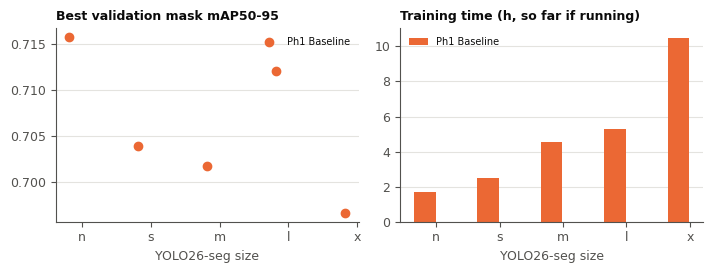

,model,phase,status,best mask mAP50-95,best box mAP50-95,hours,epochs
0,nano,phase1,complete,0.7158,0.6746,1.7024,120
1,small,phase1,complete,0.7040,0.6738,2.5037,120
2,medium,phase1,complete,0.7018,0.6953,4.5187,120
3,large,phase1,complete,0.7121,0.7060,5.2837,120
4,xlarge,phase1,complete,0.6967,0.6796,10.5049,120


⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution.


In [10]:
def section_sizes():
    runs = runs_of("phase1", "phase4")
    if not runs:
        print(missing("Phase 1 (Baseline)", "the size comparison"))
        return
    rows = []
    for r in runs:
        b = best_row(r["df"])
        rows.append({"model": r["model"], "phase": r["phase"], "status": r["status"],
                     "best mask mAP50-95": None if b is None else b.get("metrics/mAP50-95(M)"),
                     "best box mAP50-95": None if b is None else b.get("metrics/mAP50-95(B)"),
                     "hours": float(r["df"]["hours"].iloc[-1]) if "hours" in r["df"] else np.nan,
                     "epochs": int(r["df"].epoch.max())})
    val = pd.DataFrame(rows)
    models = [m for m in MODELS if m in set(val.model)]
    x = np.arange(len(models))
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    for off, ph in ((-0.18, "phase1"), (0.18, "phase4")):
        d = val[val.phase == ph].set_index("model").reindex(models)
        if d["best mask mAP50-95"].notna().any():
            axes[0].plot(x + off, d["best mask mAP50-95"], "o", color=PHASE_COLOR[ph], label=PHASE_LABEL[ph])
            axes[1].bar(x + off, d["hours"], width=0.34, color=PHASE_COLOR[ph], label=PHASE_LABEL[ph])
    for ax, t in ((axes[0], "Best validation mask mAP50-95"), (axes[1], "Training time (h, so far if running)")):
        ax.set_xticks(x, [SHORT[m] for m in models])
        ax.set_xlabel("YOLO26-seg size")
        ax.set_title(t, fontsize=9)
        ax.legend(fontsize=7)
    fig.tight_layout()
    save(fig, "internal_sizes_validation")
    plt.show()
    display(val.round(4))

    acc, eff = read_summary("test_accuracy"), read_summary("efficiency")
    if acc.empty or eff.empty:
        print(PHASE5_MISSING)
        return
    both = acc.merge(eff, on=["variant", "model", "precision"], suffixes=("", "_eff"))
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for v in ("baseline", "optimized"):
        d = both[(both.variant == v) & (both.precision == "fp32")].set_index("model").reindex(MODELS).dropna(
            subset=["params_fused"])
        axes[0].plot(d.params_fused / 1e6, d.jsi_mean, "o-" if v == "optimized" else "s--", color=VARIANT_COLOR[v],
                     label=v.capitalize())
        for m, xv, yv in zip(d.index, d.params_fused / 1e6, d.jsi_mean):
            axes[0].annotate(SHORT[m], (xv, yv), xytext=(4, -9), textcoords="offset points", fontsize=7, color=INK_2)
    for prec in ("fp32", "fp16"):
        d = both[(both.variant == "optimized") & (both.precision == prec)].set_index("model").reindex(MODELS).dropna(
            subset=["e2e_median_ms"])
        axes[1].plot(d.e2e_median_ms, d.dsc_mean, "o-" if prec == "fp32" else "^--", color=PREC_COLOR[prec],
                     label=prec.upper())
        for m, xv, yv in zip(d.index, d.e2e_median_ms, d.dsc_mean):
            axes[1].annotate(SHORT[m], (xv, yv), xytext=(4, -9), textcoords="offset points", fontsize=7, color=INK_2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("parameters (millions, fused, log)")
    axes[0].set_ylabel("test JSI")
    axes[0].set_title("Size vs. accuracy", fontsize=9)
    axes[1].set_xlabel("end-to-end median latency (ms, batch 1)")
    axes[1].set_ylabel("test DSC (Optimized)")
    axes[1].set_title("Speed vs. accuracy", fontsize=9)
    for ax in axes:
        ax.grid(True, axis="both")
        ax.legend(fontsize=7)
    fig.tight_layout()
    save(fig, "internal_sizes_tradeoffs")
    plt.show()
    cols = [c for c in ("params_fused", "gflops", "jsi_mean", "dsc_mean", "biou_mean", "hd95_mean", "fwd_median_ms",
                        "e2e_median_ms", "e2e_p95_ms", "fwd_fps") if c in both]
    display(both[both.variant == "optimized"].set_index(["model", "precision"])[cols].reindex(MODELS, level=0).round(4))


section_sizes()